# Guía práctica 2

## Ejercicio 3

In [ ]:
from matplotlib.pyplot import (
    axvline,
    figure,
    grid,
    legend,
    plot,
    show,
    title,
    xlabel,
    xlim,
    xticks,
    ylabel,
    ylim,
)
from numpy import (
    abs,
    arange,
    convolve,
    interp,
    kron,
    linspace,
    log10,
    ones,
    random,
    sinc,
    sqrt,
)
from scipy.signal import freqz

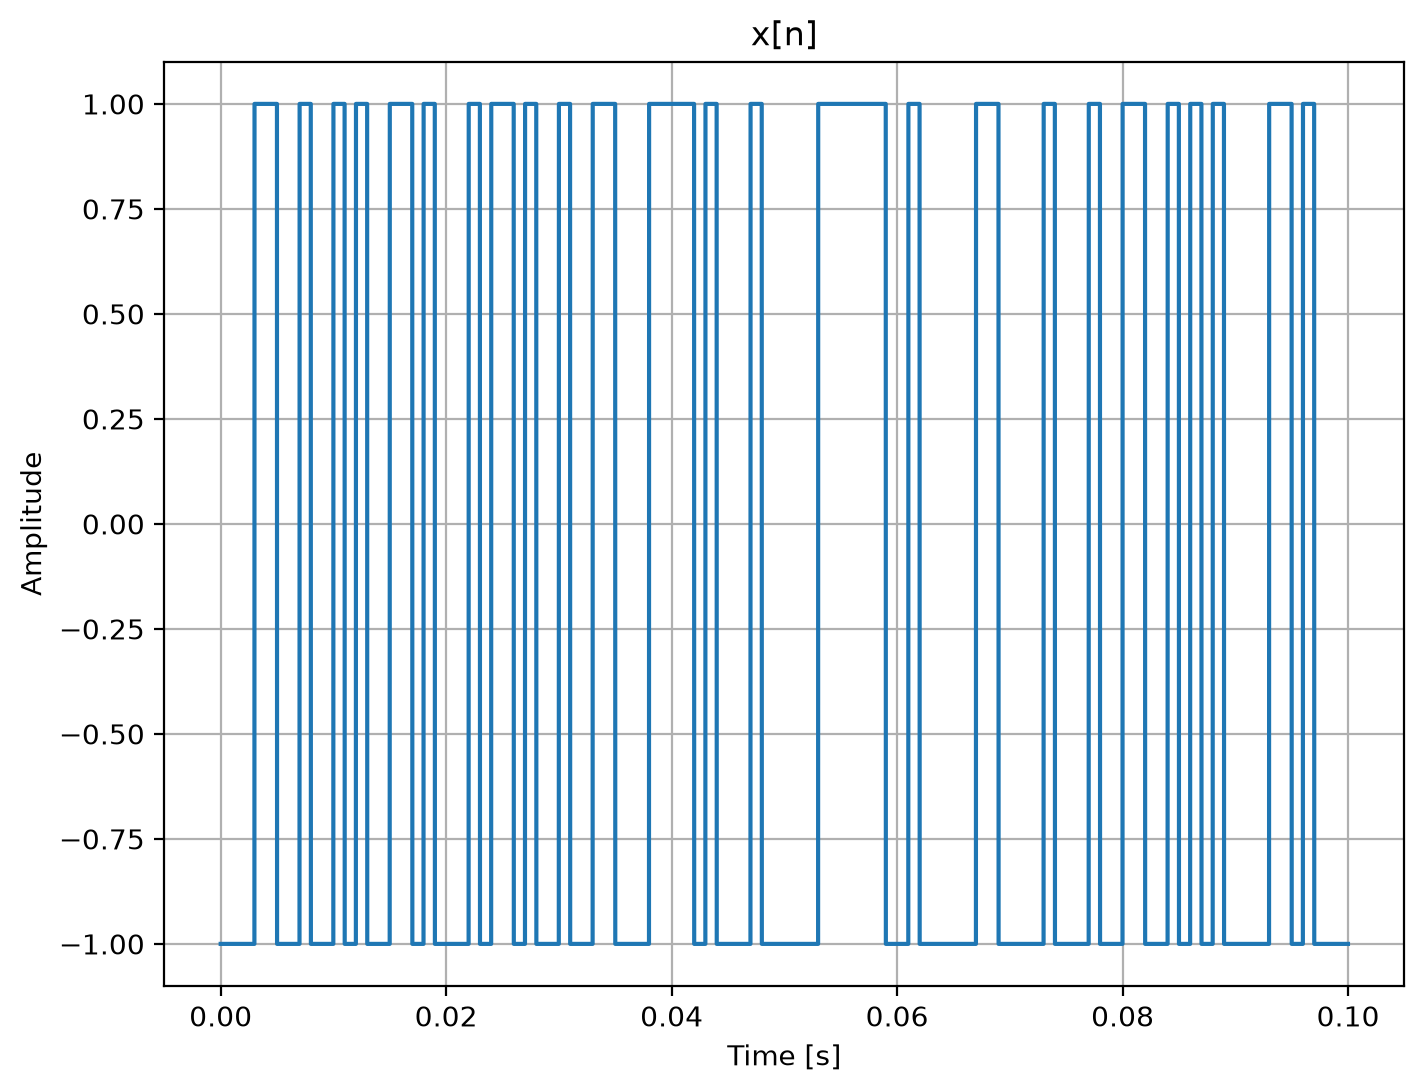

In [ ]:
sampling_freq_hz = 100e3  # "Analog" rate
bit_rate_hz = 1e3  # NRZ data rate
n_bits = 100

samples_per_bit = int(sampling_freq_hz / bit_rate_hz)
n_samples = n_bits * samples_per_bit
duration_s = n_bits / bit_rate_hz

t = arange(n_samples) / sampling_freq_hz

b = random.rand(n_bits)
B = 1 * (b > 0.5) - 1 * (b < 0.5)
x = kron(B, ones(samples_per_bit))

figure(figsize=(8, 6), dpi=200)
plot(t, x)
xlabel("Time [s]")
ylabel("Amplitude")
title("x[n]")
grid(True)
show()


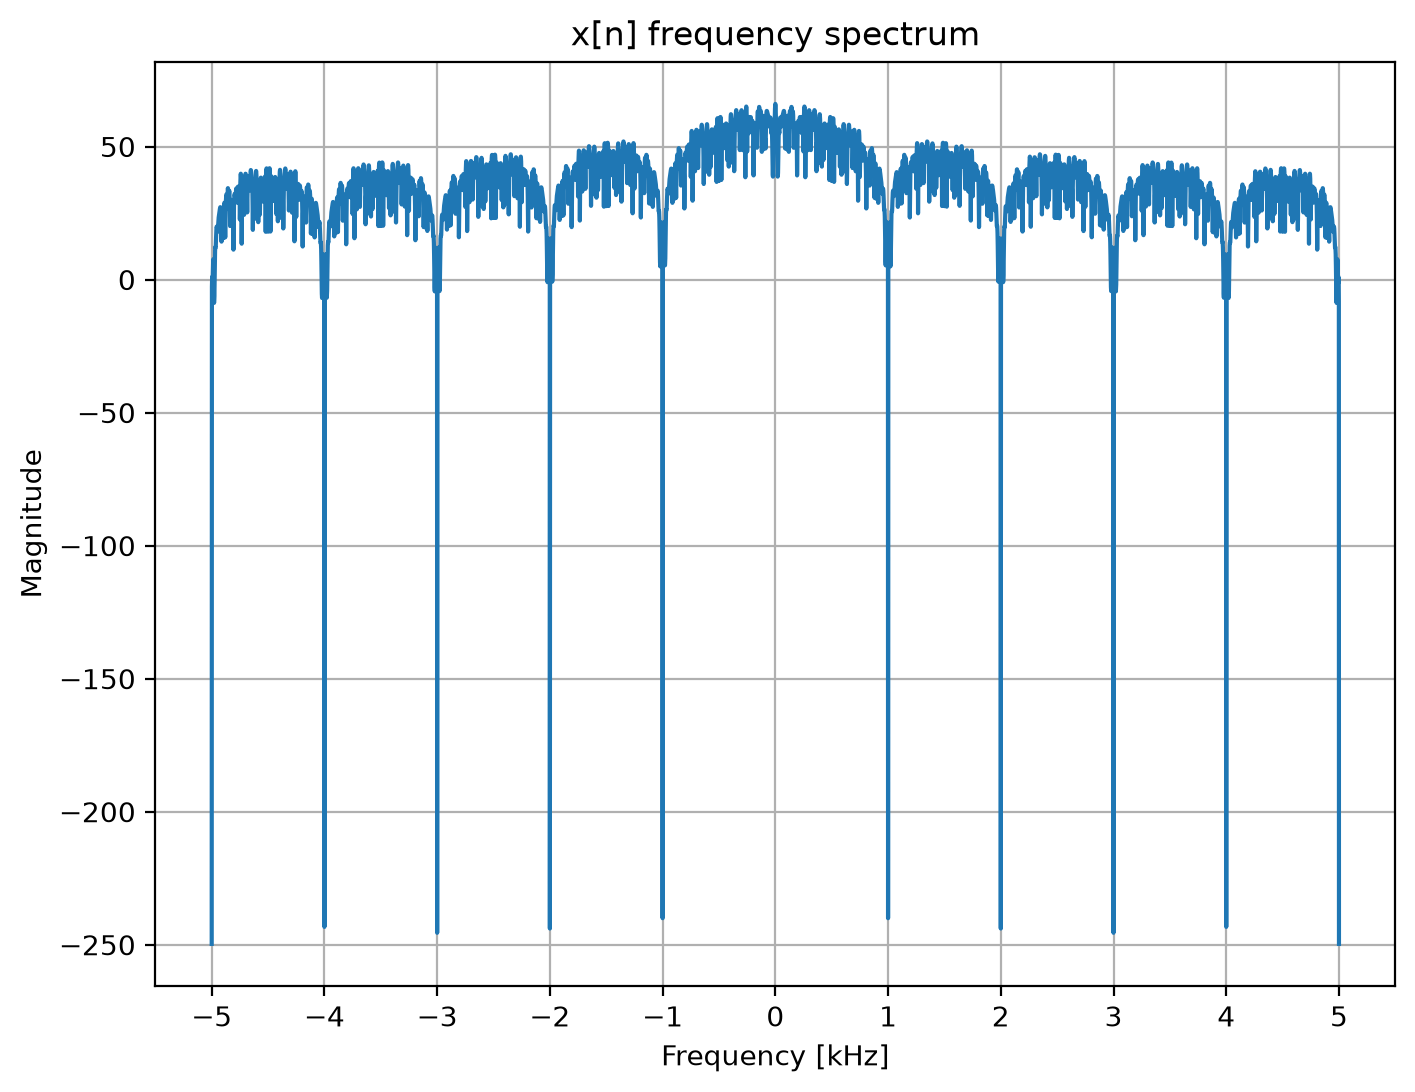

In [219]:
f_max = 5e3
f_min = -f_max

f = linspace(f_min, f_max, 10000 + 1)
f_khz = f / 1e3
f, H = freqz(x, worN=f, fs=sampling_freq_hz)

figure(figsize=(8, 6), dpi=200)
plot(f_khz, 20 * log10(abs(H)))
xlabel("Frequency [kHz]")
ylabel("Magnitude")
xticks(arange(f_min / 1e3, f_max / 1e3 + 1, 1))
title("x[n] frequency spectrum")
grid(True)
show()

## Filtro pasa bajos

In [220]:
lpf_cutoff_hz = 1e3
lpf_duration_s = 3e-3

# Ideal LPF: h(t) = 2*fc*sinc(2*fc*t) -> zeros every 1/(2*fc) = 0.5 ms.
zero_crossing_samples = sampling_freq_hz / (2 * lpf_cutoff_hz)  # 50
n_taps_half = int(lpf_duration_s * sampling_freq_hz) // 2  # 150

n = arange(-n_taps_half, n_taps_half)
h = sinc(n / zero_crossing_samples)
h = h / h.sum()

y = convolve(x, h, "full")[n_taps_half : -n_taps_half + 1]

Muestreo (diezmado) de la señal "analógica" y cálculo (diezmado) del filtro digital a partir de la respuesta del filtro analógico:

In [221]:
decimation_factor = 10
digital_freq_hz = sampling_freq_hz / decimation_factor  # 10 kHz

r = random.randn(y.size)
w = y + r

wd = w[::decimation_factor]  # Signal sampled at 10 kHz.
td = arange(wd.size) / digital_freq_hz

hd = decimation_factor * h[::decimation_factor]
n_taps_half_d = n_taps_half // decimation_factor

## (b) Respuesta en frecuencia del filtro pasa bajos

Gráfico de la respuesta del filtro "analógico" $h(t)$ y la de su contraparte digital
$h_d[n]$. Como $h_d[n]$ opera a $f_s = 10kHz$, su respuesta es periódica con esa
tasa y sólo tiene sentido hasta $5kHz$.

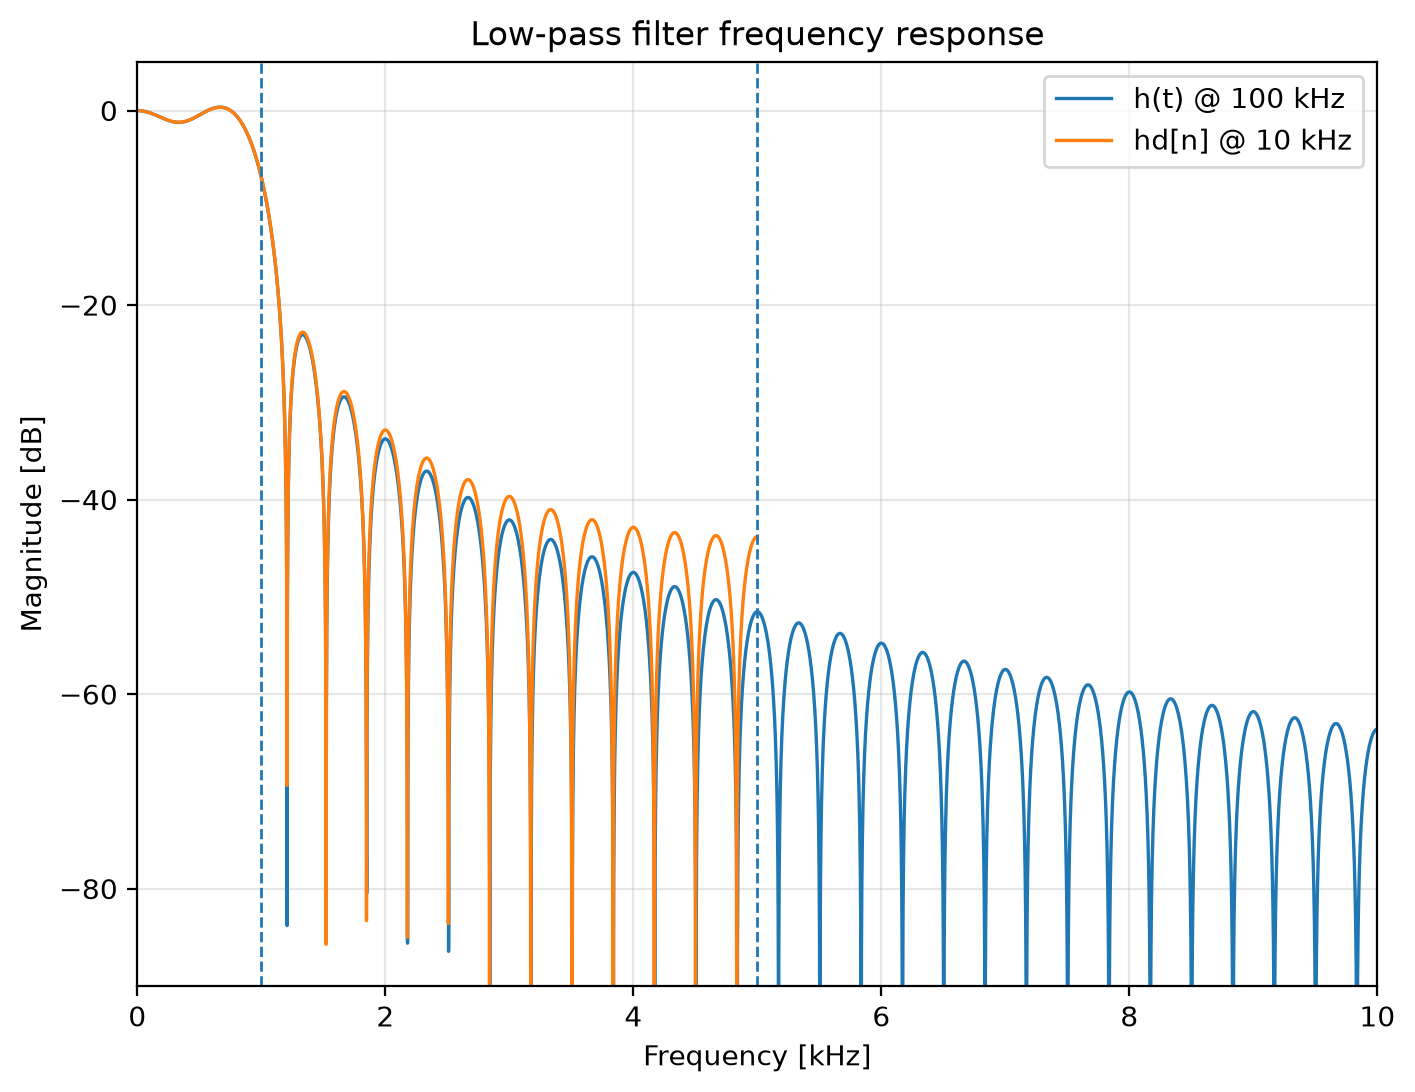

In [222]:
f = linspace(0, 10e3, 10000 + 1)
_, H = freqz(h, worN=f, fs=sampling_freq_hz)

fd = linspace(0, digital_freq_hz / 2, 5000 + 1)
_, Hd = freqz(hd, worN=fd, fs=digital_freq_hz)

figure(figsize=(8, 6), dpi=200)
plot(f / 1e3, 20 * log10(abs(H)), linewidth=1.2, label="h(t) @ 100 kHz")
plot(
    fd / 1e3,
    20 * log10(abs(Hd)),
    linewidth=1.2,
    label="hd[n] @ 10 kHz",
)
axvline(lpf_cutoff_hz / 1e3, linestyle="--", linewidth=1)
axvline(digital_freq_hz / 2e3, linestyle="--", linewidth=1)
xlabel("Frequency [kHz]")
ylabel("Magnitude [dB]")
title("Low-pass filter frequency response")
xlim(0, 10)
ylim(-90, 5)
legend()
grid(True, alpha=0.3)
show()

## (c) Señales recibidas $s(t)$ y $u(t)$

Según el diagrama, la señal recibida se filtra con el **mismo** pasa bajos usado antes
de transmitir: $s(t)$ es el camino limpio ($y$ sin ruido) y $u(t)$ el camino con ruido
($w = y + r$). Ambos son filtrados en "analógico", es decir a $100kHz$.

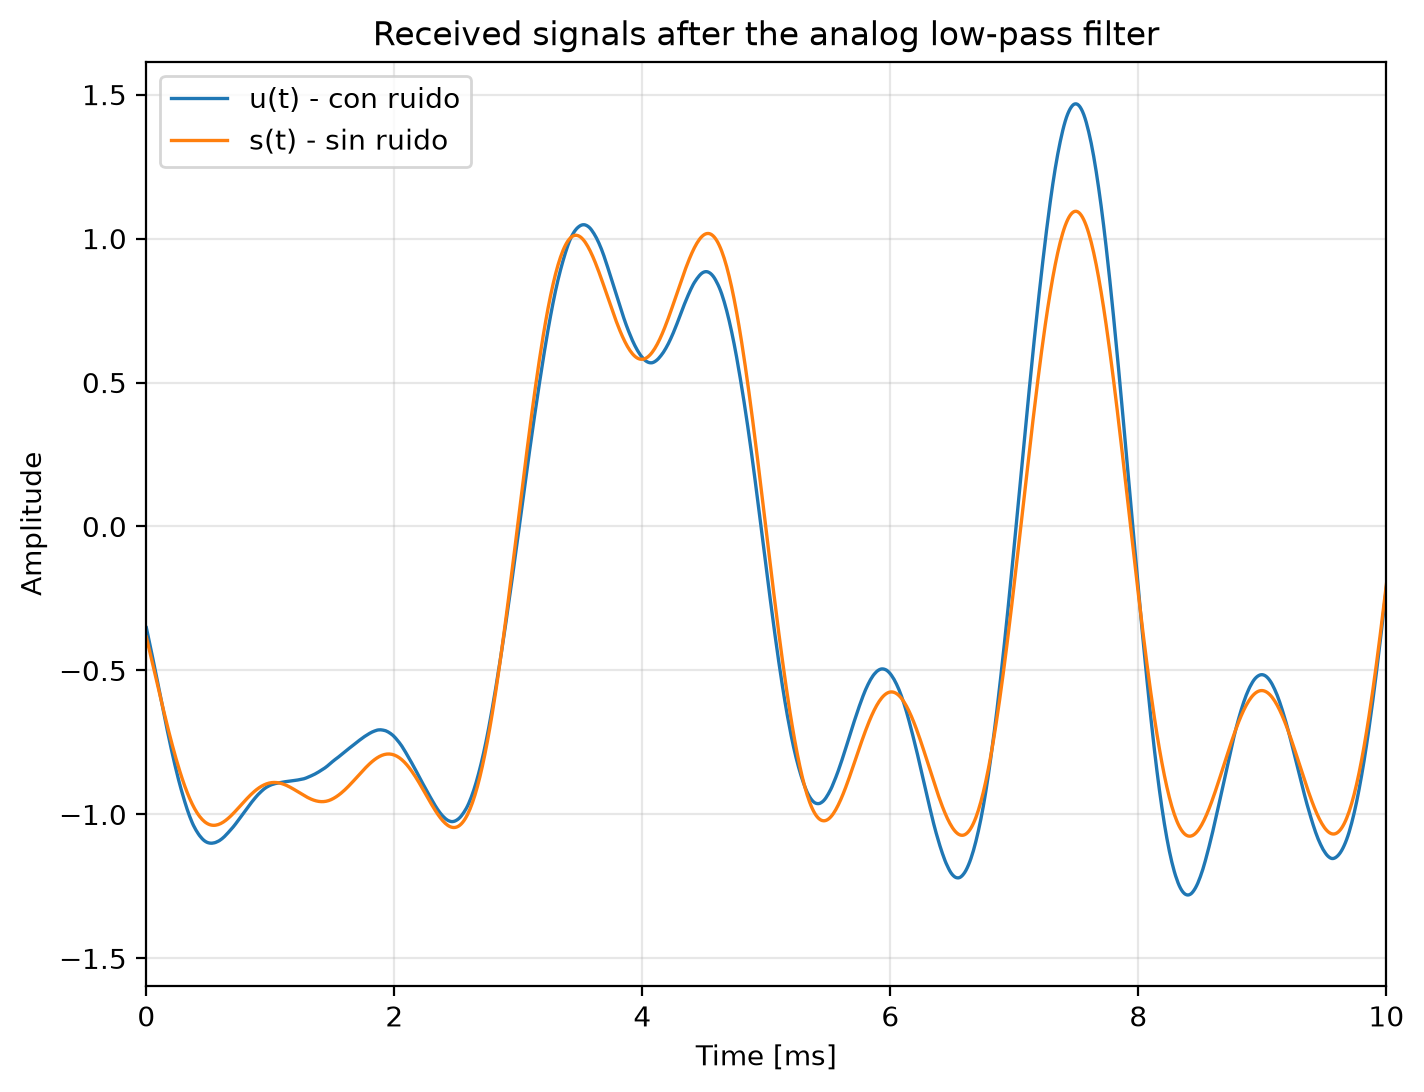

In [223]:
s = convolve(y, h, "full")[n_taps_half : -n_taps_half + 1]
u = convolve(w, h, "full")[n_taps_half : -n_taps_half + 1]

plot_window_s = 10e-3

figure(figsize=(8, 6), dpi=200)
plot(t * 1e3, u, linewidth=1.2, label="u(t) - con ruido")
plot(t * 1e3, s, linewidth=1.2, label="s(t) - sin ruido")
xlabel("Time [ms]")
ylabel("Amplitude")
title("Received signals after the analog low-pass filter")
xlim(0, plot_window_s * 1e3)
legend()
grid(True, alpha=0.3)
show()

El filtro pasa bajos elimina casi todo el ruido: $u(t)$ sigue de cerca a $s(t)$ y las
decisiones de bit se toman sin error.

## (d) Procesamiento digital y reconstrucción

Ahora el mismo filtrado pero por el camino digital: se muestrea $w(t)$ a $10kHz$
(obteniendo $w_d[n]$), se filtra con $h_d[n]$ y se reconstruye $v(t)$ interpolando de
vuelta a $100kHz$.

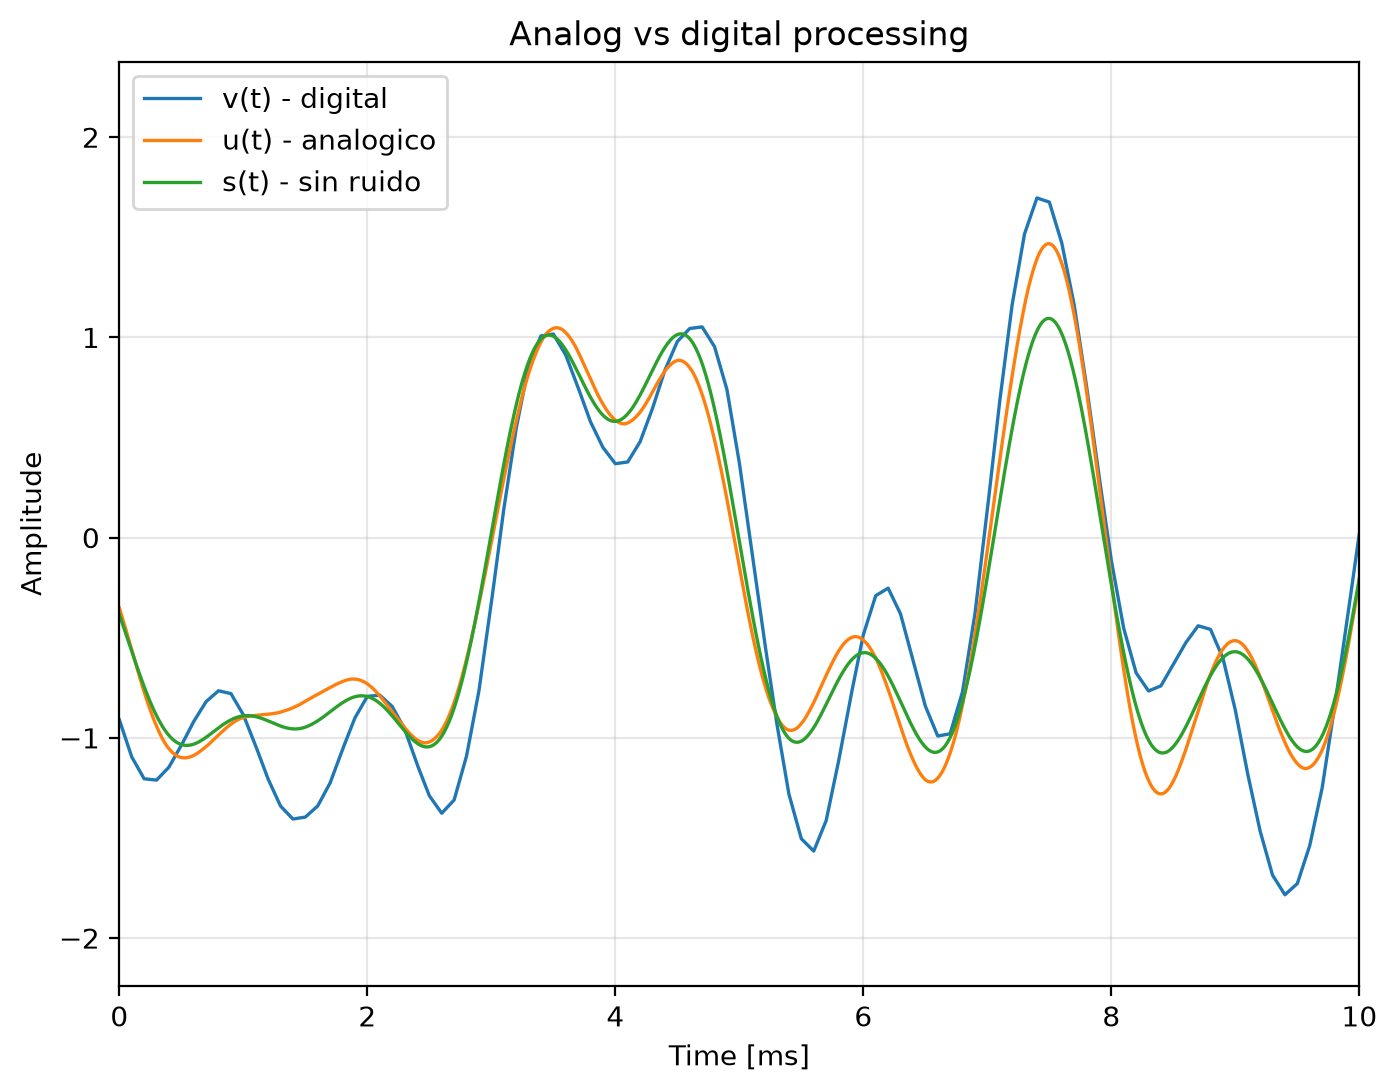

In [224]:
ud = convolve(wd, hd, "full")[n_taps_half_d : -n_taps_half_d + 1]
v = interp(t, td, ud)

t_ms = t * 1e3

figure(figsize=(8, 6), dpi=200)
plot(t_ms, v, linewidth=1.2, label="v(t) - digital")
plot(t_ms, u, linewidth=1.2, label="u(t) - analogico")
plot(t_ms, s, linewidth=1.2, label="s(t) - sin ruido")
xlabel("Time [ms]")
ylabel("Amplitude")
title("Analog vs digital processing")
xlim(0, plot_window_s * 1e3)
legend()
grid(True, alpha=0.3)
show()

In [225]:
noise_power_u = ((u - s) ** 2).mean()
noise_power_v = ((v - s) ** 2).mean()

print(f"Potencia de ruido residual en u(t): {noise_power_u:.4f}")
print(f"Potencia de ruido residual en v(t): {noise_power_v:.4f}")
print(
    f"Relacion v/u: {noise_power_v / noise_power_u:.1f}x"
    f" = {10 * log10(noise_power_v / noise_power_u):.1f} dB"
)

Potencia de ruido residual en u(t): 0.0172
Potencia de ruido residual en v(t): 0.1816
Relacion v/u: 10.5x = 10.2 dB


$v(t)$ sale claramente más ruidosa que $u(t)$: la potencia de ruido residual es del
orden de $10$ veces mayor. El valor exacto cambia en cada corrida porque `B` y `r` son aleatorios y se está midiendo una sola realización.

El problema es el **orden de las operaciones**, no el filtro:

- En el camino analógico el ruido se filtra *antes* de cualquier muestreo, así que las componentes por encima de $1kHz$ se eliminan y no molestan. 
- En el camino digital se muestrea $w(t)$ con su ruido de ancho de banda completo, $50kHz$ a sólo $10kHz$, lo que hace que todo ese ruido se repliegue sobre la banda base y la densidad espectral
dentro de la banda queda $\times 10$. Recién después actúa el filtro $h_d[n]$.

## (e) El replicado equivale a multiplicar la potencia de ruido por 10

Si la interpretación de (d) es correcta, entonces el camino digital debería comportarse igual que el camino analógico alimentado con un ruido $10$ veces más potente, es decir $w = y + \sqrt{10}r$.

In [239]:
u10 = convolve(y + sqrt(10) * r, h, "full")[n_taps_half : -n_taps_half + 1]

noise_power_u10 = ((u10 - s) ** 2).mean()

print(f"Ruido en u(t) con r          : {noise_power_u:.4f}")
print(
    f"Ruido en u(t) con sqrt(10)*r : {noise_power_u10:.4f}"
    f"  ({noise_power_u10 / noise_power_u:.2f}x)"
)
print(
    f"Ruido en v(t)                : {noise_power_v:.4f}"
    f"  ({noise_power_v / noise_power_u:.2f}x)"
)


Ruido en u(t) con r          : 0.0172
Ruido en u(t) con sqrt(10)*r : 0.1723  (10.00x)
Ruido en v(t)                : 0.1816  (10.54x)


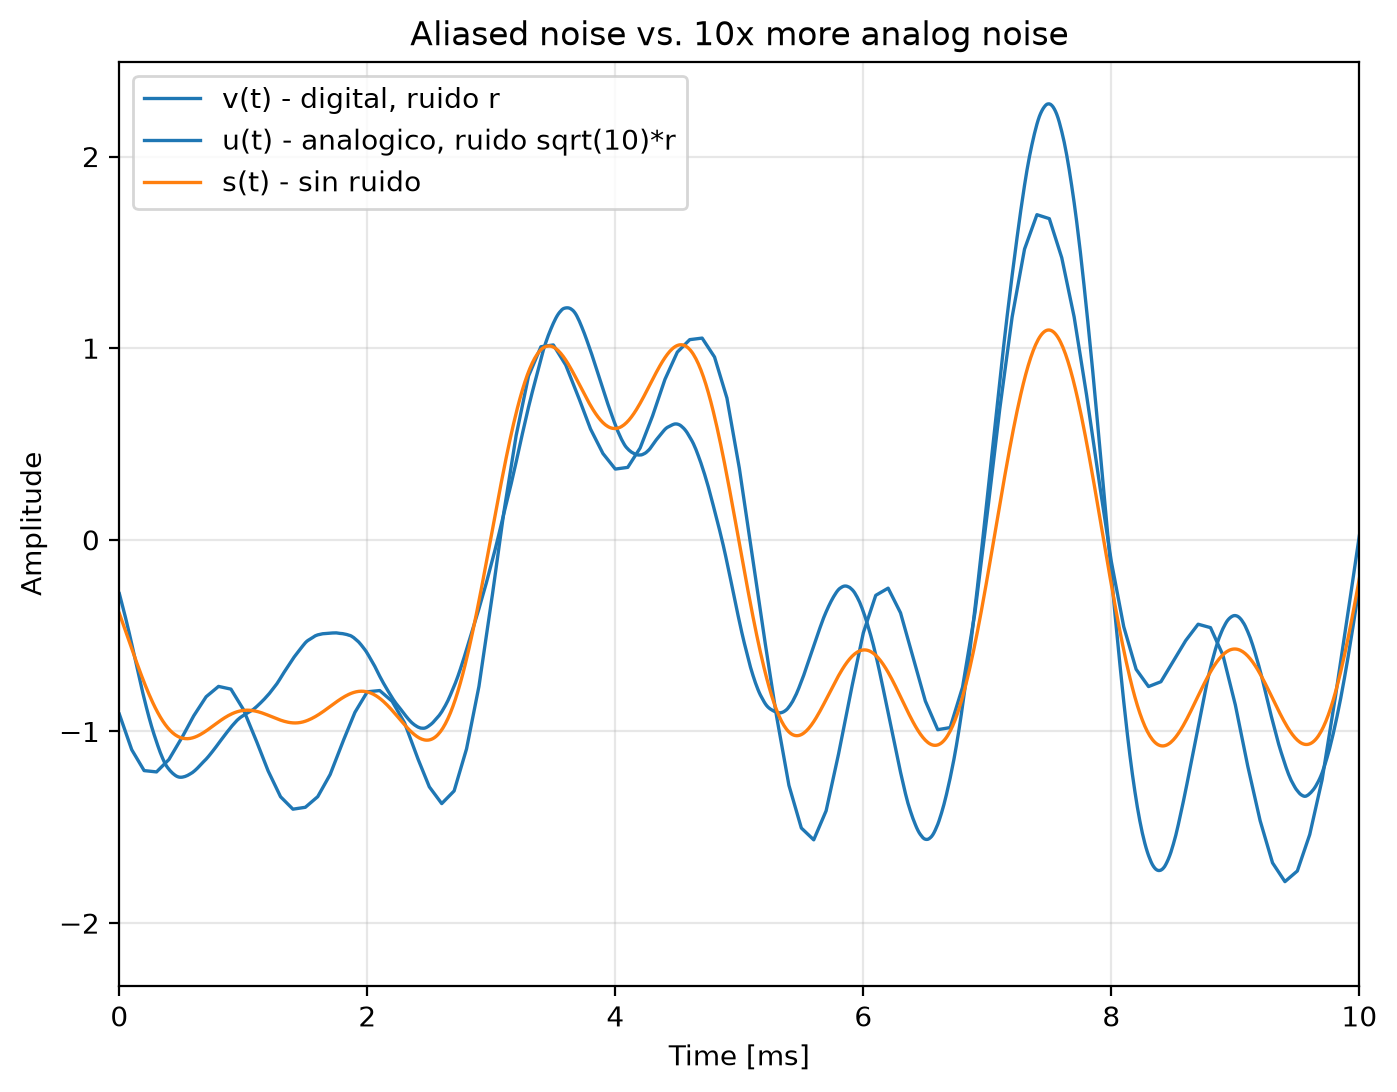

In [ ]:
figure(figsize=(8, 6), dpi=200)
plot(t_ms, v, linewidth=1.2, label="v(t) - digital, ruido r")
plot(
    t_ms,
    u10,
    linewidth=1.2,
    label="u(t) - analogico, ruido sqrt(10)*r",
)
plot(t_ms, s, linewidth=1.2, label="s(t) - sin ruido")
xlabel("Time [ms]")
ylabel("Amplitude")
title("Aliased noise vs. 10x more analog noise")
xlim(0, plot_window_s * 1e3)
legend()
grid(True, alpha=0.3)
show()

Queda confirmado que el muestreo no agrega ruido nuevo sino que redistribuye el que ya estaba. Las 10 réplicas del espectro de ruido que caen dentro de la banda base se suman en potencia, y por eso la densidad espectral en la banda útil queda multiplicada por el factor de diezmado.

## (f) Diseño del filtro anti-aliasing $h_a(t)$

El filtro tiene que limitar $w(t)$ a la banda que el muestreo a $10$kHz puede representar, o sea cortar en $f_s/2 = 5kHz$. Se usa el mismo método que para $h(t)$, una *sinc* ideal truncada a $3ms$

In [ ]:
aa_cutoff_hz = digital_freq_hz / 2
aa_zero_crossing_samples = sampling_freq_hz / (2 * aa_cutoff_hz)
n_taps_half_a = int(lpf_duration_s * sampling_freq_hz) // 2

na = arange(-n_taps_half_a, n_taps_half_a)
ha = sinc(na / aa_zero_crossing_samples)
ha = ha / ha.sum()

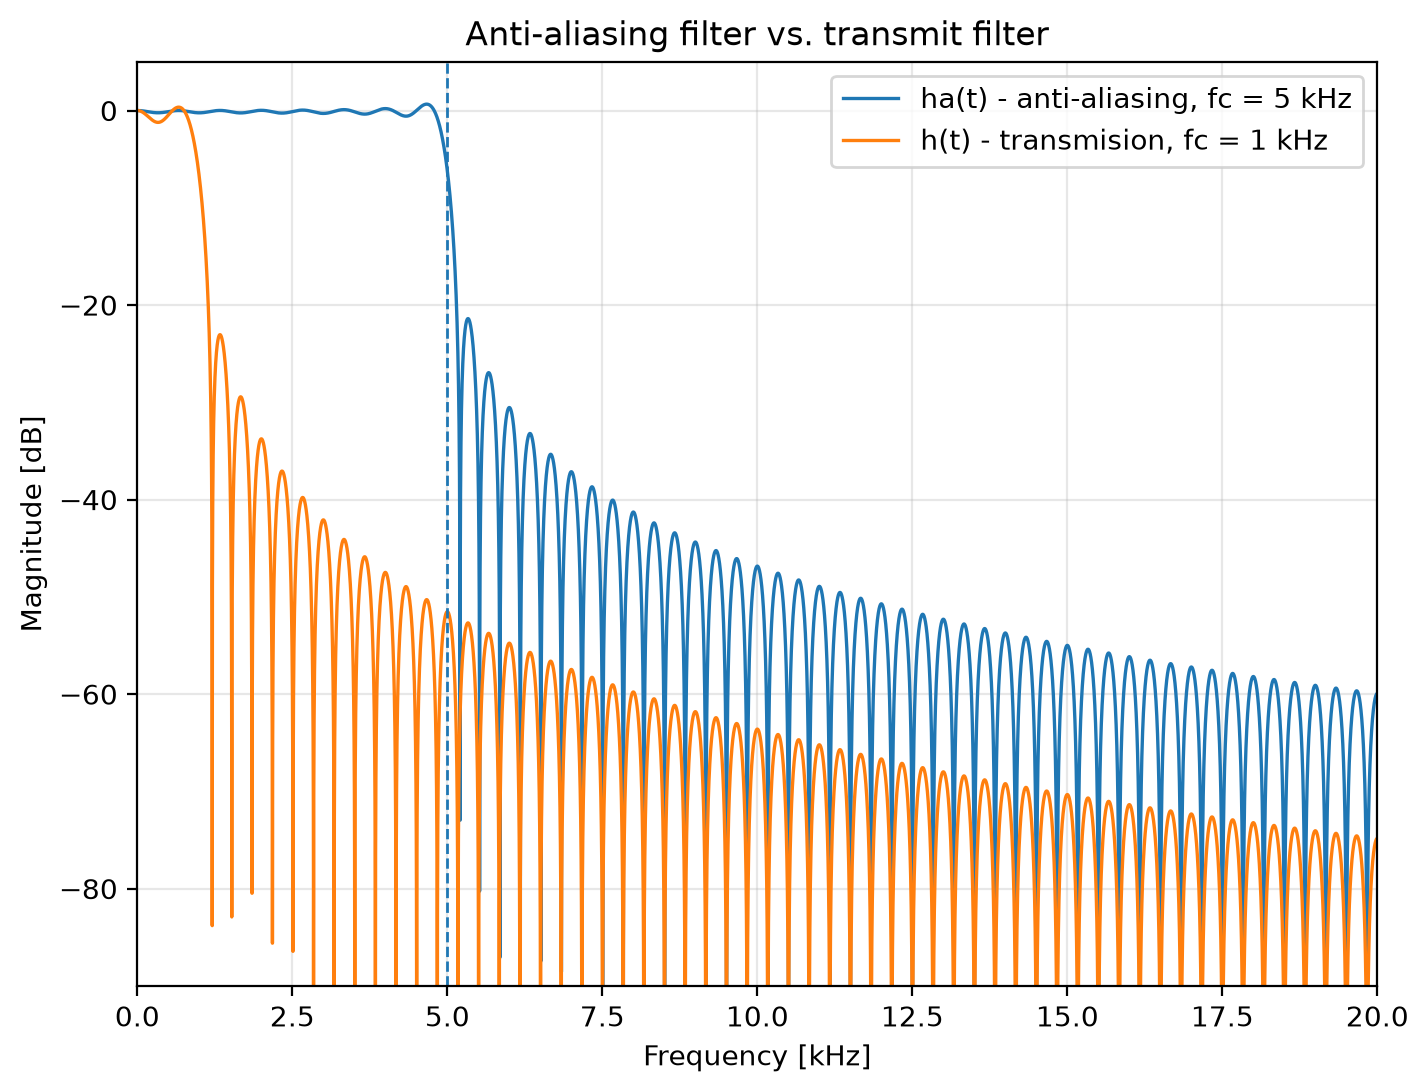

In [246]:
f = linspace(0, 20e3, 20000 + 1)
_, Ha = freqz(ha, worN=f, fs=sampling_freq_hz)
_, H = freqz(h, worN=f, fs=sampling_freq_hz)

figure(figsize=(8, 6), dpi=200)
plot(
    f / 1e3,
    20 * log10(abs(Ha)),
    linewidth=1.2,
    label="ha(t) - anti-aliasing, fc = 5 kHz",
)
plot(
    f / 1e3,
    20 * log10(abs(H)),
    linewidth=1.2,
    label="h(t) - transmision, fc = 1 kHz",
)
axvline(aa_cutoff_hz / 1e3, linestyle="--", linewidth=1)
xlabel("Frequency [kHz]")
ylabel("Magnitude [dB]")
title("Anti-aliasing filter vs. transmit filter")
xlim(0, 20)
ylim(-90, 5)
legend()
grid(True, alpha=0.3)
show()

## (g) Procesamiento digital con filtro anti-aliasing

Se repite la cadena de (d) —muestreo, filtrado digital y reconstrucción— pero filtrando
$w(t)$ con $h_a(t)$ **antes** del muestreador.

In [ ]:
wa = convolve(w, ha, "full")[n_taps_half_a : -n_taps_half_a + 1]
wad = wa[::decimation_factor]

uad = convolve(wad, hd, "full")[n_taps_half_d : -n_taps_half_d + 1]
va = interp(t, td, uad)

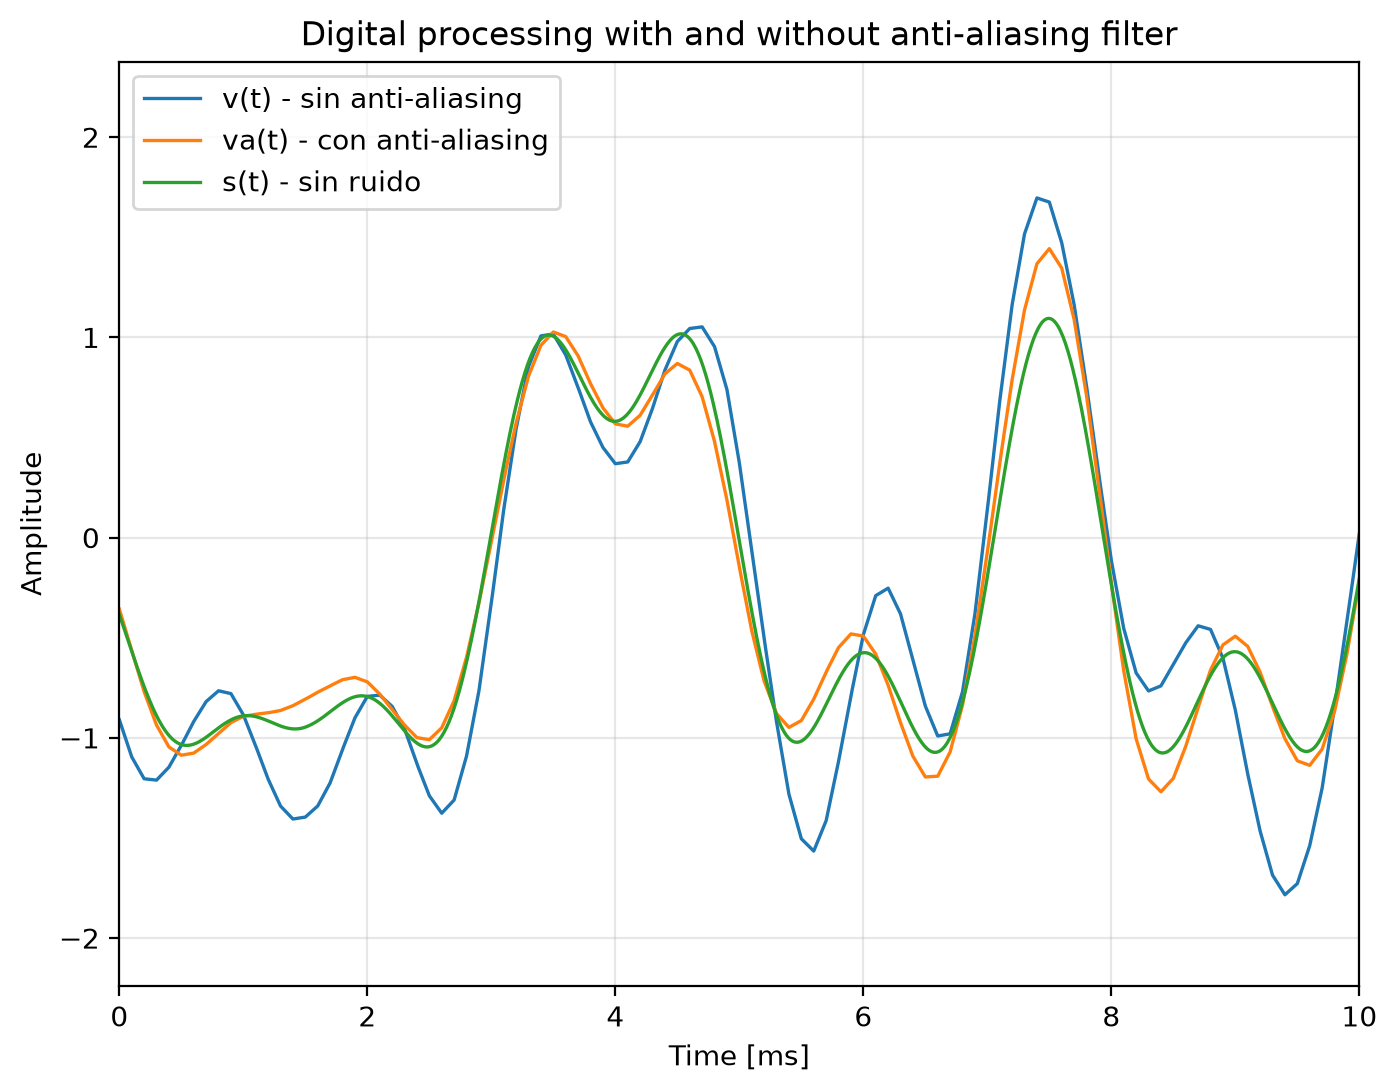

In [253]:
figure(figsize=(8, 6), dpi=200)
plot(t_ms, v, linewidth=1.2, label="v(t) - sin anti-aliasing")
plot(t_ms, va, linewidth=1.2, label="va(t) - con anti-aliasing")
plot(t_ms, s, linewidth=1.2, label="s(t) - sin ruido")
xlabel("Time [ms]")
ylabel("Amplitude")
title("Digital processing with and without anti-aliasing filter")
xlim(0, plot_window_s * 1e3)
legend()
grid(True, alpha=0.3)
show()

In [ ]:
noise_power_va = ((va - s) ** 2).mean()

print(f"Ruido en v(t)  sin anti-aliasing : {noise_power_v:.4f}")
print(f"Ruido en va(t) con anti-aliasing : {noise_power_va:.4f}")
print(f"Ruido en u(t)  analogico         : {noise_power_u:.4f}")
print(f"Mejora: {10 * log10(noise_power_v / noise_power_va):.1f} dB")

Ruido en v(t)  sin anti-aliasing : 0.1816
Ruido en va(t) con anti-aliasing : 0.0169
Ruido en u(t)  analogico         : 0.0172
Mejora: 10.3 dB
